# Copying a Solana wallet is a latency problem

**Replay results across 26,685 bonding-curve trades.**

If you mirror a profitable pump.fun wallet trade for trade, one slot behind, do you make
money? And if not, is the fix better exit rules — or something else entirely?

This notebook answers that from a full replay of the bonding curve. Every figure and every
number below is computed from `metrics.json`, which
[`scripts/export-metrics.js`](../scripts/export-metrics.js) derives by re-running the
engine. Nothing here is transcribed by hand.

> **The short answer: no, and the exits are not the problem.**
> Every parameter combination tested loses money. The loss is created at entry, before any
> exit rule has a chance to act.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

METRICS = json.loads(Path("metrics.json").read_text(encoding="utf-8"))

base = METRICS["baseline"]["stats"]
trades = METRICS["baseline"]["trades"]
exits = METRICS["baseline"]["exitReasons"]
latency = METRICS["latency"]
grid = METRICS["grid"]

# Palette: categorical slots 1 and 2 plus the blue/red diverging pair, and a
# single-hue blue ramp for magnitude. Figures are drawn on an explicit white
# ground so they stay legible in both GitHub themes.
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
RAMP = ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "figure.dpi": 130,
    "font.size": 9,
    "text.color": INK,
    "axes.labelcolor": MUTED,
    "axes.edgecolor": GRID,
    "axes.titlesize": 11,
    "axes.titleweight": "600",
    "axes.titlecolor": INK,
    "axes.titlepad": 12,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelcolor": MUTED,
    "ytick.labelcolor": MUTED,
    "grid.color": GRID,
    "legend.frameon": False,
})


def style(ax, grid_axis="y"):
    """Recede the chrome so the data carries the figure."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.grid(True, axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    return ax


MINUS = "\u2212"  # typographic minus, so figures and prose agree


def sol(v, digits=3):
    sign = "+" if v >= 0 else MINUS
    return f"{sign}{abs(v):.{digits}f} SOL"


def pct(v, digits=1):
    sign = MINUS if v < 0 else ""
    return f"{sign}{abs(v):.{digits}f}%"

## Method

The engine mirrors every `BUY` and `SWAP` made by one target wallet and fills **on the slot
after** the wallet's own transaction — roughly 400 ms on Solana, and the honest assumption
for any copy bot that has to observe a trade before it can react to one.

Fills are reconstructed from the constant-product bonding curve using the virtual token and
SOL reserves recorded at that slot, in exact integer arithmetic, rather than approximated
from market-cap snapshots. Positions close on whichever of seven rules fires first:
take-profit, stop-loss, trailing stop, break-even protection, max hold, momentum failure,
or holder concentration. Fees are charged at 1.5% per side.

## Baseline result

In [2]:
rows = [
    ("Total PnL",          sol(base["totalPnl"])),
    ("Win rate",           pct(base["winRate"])),
    ("Round trips",        f"{base['trades']}"),
    ("Profit factor",      f"{base['profitFactor']:.2f}"),
    ("Max drawdown",       f"{base['maxDrawdown']:.2f} SOL"),
    ("Return on capital",  pct(base["returnOnCapitalPct"])),
    ("Median hold",        f"{base['medianHoldSec']:.1f} s"),
    ("Fees paid",          f"{base['totalFees']:.2f} SOL"),
]

display(Markdown(
    "| Metric | Value |\n|---|---|\n"
    + "\n".join(f"| {k} | **{v}** |" for k, v in rows)
    + f"\n\nDataset: **{METRICS['dataset']['tokenCount']} tokens**, "
      f"**{METRICS['dataset']['tradeCount']:,} trades**, target wallet "
      f"`{METRICS['dataset']['targetWallet'][:8]}…`."
))

| Metric | Value |
|---|---|
| Total PnL | **−5.930 SOL** |
| Win rate | **25.0%** |
| Round trips | **68** |
| Profit factor | **0.31** |
| Max drawdown | **5.93 SOL** |
| Return on capital | **−10.9%** |
| Median hold | **11.7 s** |
| Fees paid | **1.57 SOL** |

Dataset: **68 tokens**, **26,685 trades**, target wallet `DDDD2zvz…`.

### Equity curve

Cumulative PnL after each closed position, in exit order. The line is monotonically unkind:
there is no regime in the sample where the strategy works and a later one where it stops.

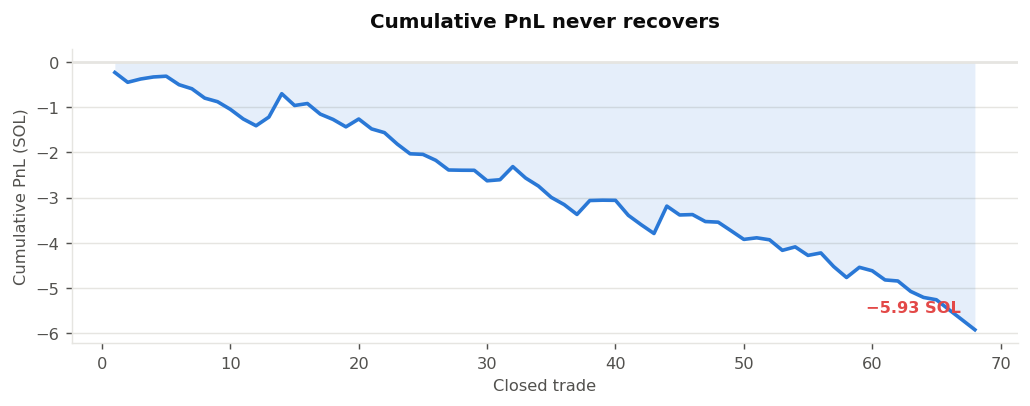

In [3]:
eq = base["equityCurve"]
x = [p["trade"] for p in eq]
y = [p["equity"] for p in eq]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.axhline(0, color=GRID, linewidth=1.5)
ax.fill_between(x, y, 0, color=BLUE, alpha=0.12, linewidth=0)
ax.plot(x, y, color=BLUE, linewidth=2)
ax.set_xlabel("Closed trade")
ax.set_ylabel("Cumulative PnL (SOL)")
ax.set_title("Cumulative PnL never recovers")
style(ax)
ax.annotate(
    sol(base["totalPnl"], 2),
    xy=(x[-1], y[-1]), xytext=(-8, 10), textcoords="offset points",
    ha="right", color=RED, fontweight="600",
)
plt.tight_layout()
plt.show()

### Where the money goes, trade by trade

The losses are not fat tails — they are a steady bleed of similar-sized stop-outs, which is
what a structural cost looks like rather than bad luck.

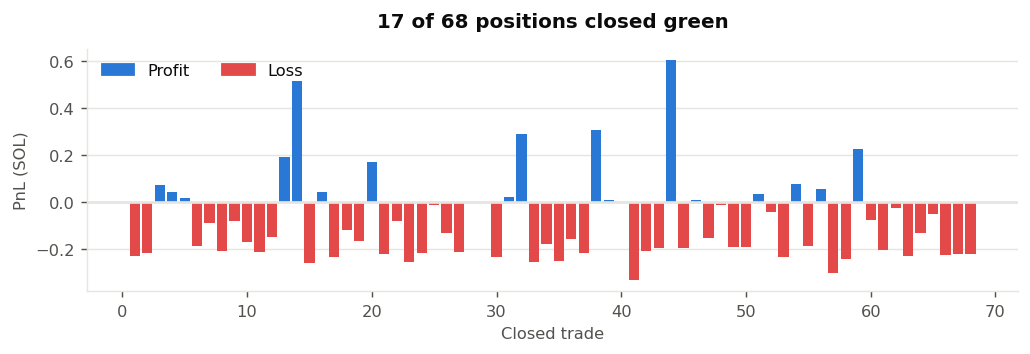

In [4]:
pnls = [t["pnl"] for t in trades]
colors = [BLUE if p > 0 else RED for p in pnls]

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.axhline(0, color=GRID, linewidth=1.5)
ax.bar(range(1, len(pnls) + 1), pnls, color=colors, width=0.82)
ax.set_xlabel("Closed trade")
ax.set_ylabel("PnL (SOL)")
ax.set_title(f"{base['winCount']} of {base['trades']} positions closed green")
style(ax)
handles = [
    mpl.patches.Patch(color=BLUE, label="Profit"),
    mpl.patches.Patch(color=RED, label="Loss"),
]
ax.legend(handles=handles, loc="upper left", ncols=2)
plt.tight_layout()
plt.show()

### Which exit rule fired, and what it cost

Each position is attributed to the rule that closed it. The exit logic works on positions
that survive long enough to use it — trailing stop and take-profit are both net positive.
The damage is done before that.

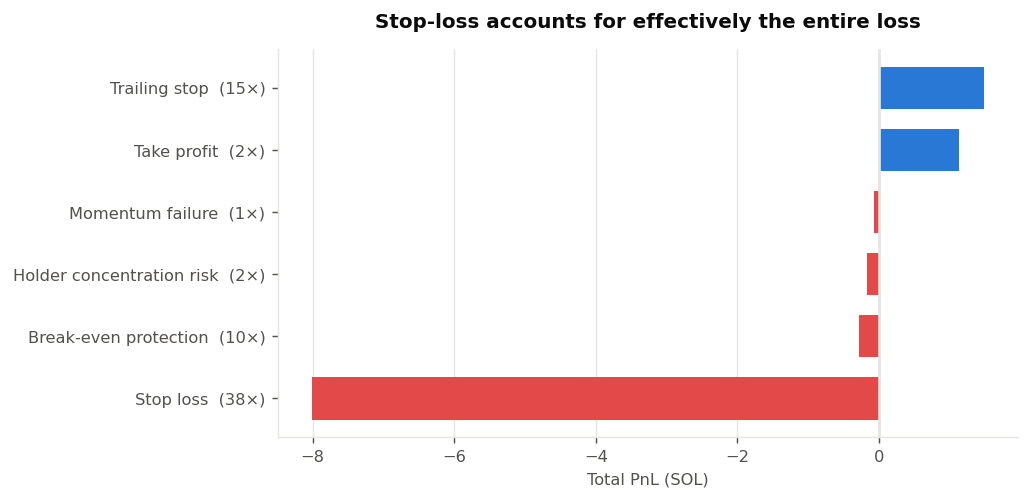

In [5]:
order = sorted(exits, key=lambda e: e["pnl"])
# The count rides on the category label; annotating the bar tip collides with
# the axis as soon as a bar reaches the left edge.
labels = [f"{e['reason']}  ({e['count']}\u00d7)" for e in order]
vals = [e["pnl"] for e in order]

fig, ax = plt.subplots(figsize=(8, 0.42 * len(order) + 1.4))
ax.axvline(0, color=GRID, linewidth=1.5)
ax.barh(labels, vals, color=[BLUE if v > 0 else RED for v in vals], height=0.68)
ax.set_xlabel("Total PnL (SOL)")
ax.set_title("Stop-loss accounts for effectively the entire loss")
style(ax, grid_axis="x")
plt.tight_layout()
plt.show()

## Can better exits fix it?

Every combination of take-profit and stop-loss on a 10 × 8 grid, re-running the **full
replay** for each cell — not reweighting a single run. If tuning could rescue this
strategy, a profitable cell would appear somewhere on this surface.

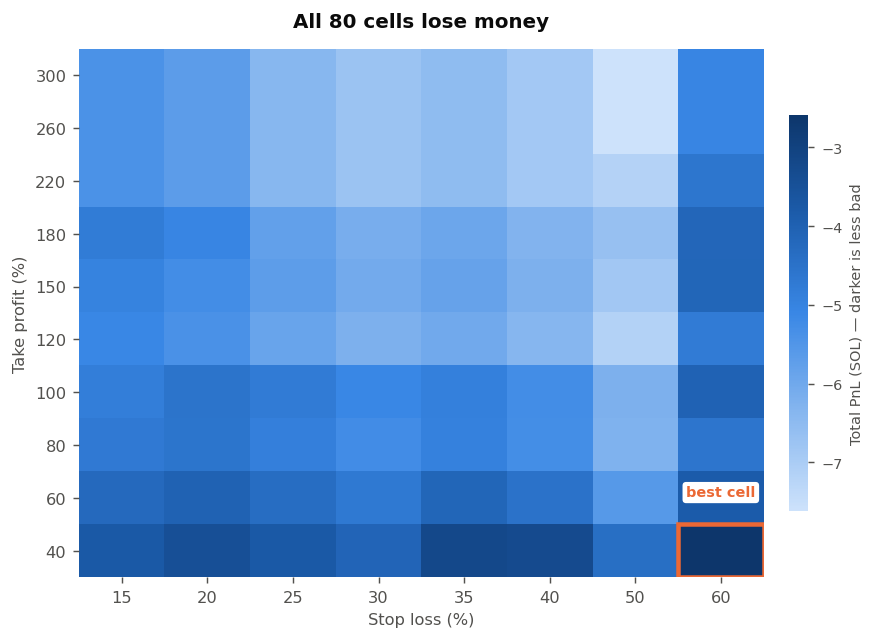

**No cell is profitable.** The best one — take-profit **40%** with stop-loss **60%** — still loses **−2.586 SOL**. It widens the stop until positions are given room to recover, lifting the win rate to 44.1% without reaching break-even.

In [6]:
tps = sorted({g["takeProfitPercent"] for g in grid}, reverse=True)
sls = sorted({g["stopLossPercent"] for g in grid})
Z = np.full((len(tps), len(sls)), np.nan)
lookup = {(g["takeProfitPercent"], g["stopLossPercent"]): g["totalPnl"] for g in grid}
for i, tp in enumerate(tps):
    for j, sl in enumerate(sls):
        Z[i, j] = lookup[(tp, sl)]

cmap = mpl.colors.LinearSegmentedColormap.from_list("blues", RAMP)
fig, ax = plt.subplots(figsize=(7.2, 5))
im = ax.imshow(Z, cmap=cmap, aspect="auto")
ax.set_xticks(range(len(sls)), [f"{v}" for v in sls])
ax.set_yticks(range(len(tps)), [f"{v}" for v in tps])
ax.set_xlabel("Stop loss (%)")
ax.set_ylabel("Take profit (%)")
ax.set_title("All 80 cells lose money")
ax.grid(False)
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)

best = max(grid, key=lambda g: g["totalPnl"])
bi, bj = tps.index(best["takeProfitPercent"]), sls.index(best["stopLossPercent"])
ax.add_patch(mpl.patches.Rectangle(
    (bj - 0.5, bi - 0.5), 1, 1, fill=False, edgecolor=ORANGE, linewidth=2.5,
))
ax.annotate(
    "best cell", xy=(bj, bi), xytext=(0, 30), textcoords="offset points",
    ha="center", color=ORANGE, fontsize=8, fontweight="600",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none"),
)
cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.03)
cbar.set_label("Total PnL (SOL) — darker is less bad", color=MUTED, fontsize=8)
cbar.ax.tick_params(colors=MUTED, labelsize=8)
cbar.outline.set_visible(False)
plt.tight_layout()
plt.show()

display(Markdown(
    f"**No cell is profitable.** The best one — take-profit "
    f"**{best['takeProfitPercent']}%** with stop-loss **{best['stopLossPercent']}%** — still "
    f"loses **{sol(best['totalPnl'])}**. It widens the stop until positions are given room "
    f"to recover, lifting the win rate to {pct(best['winRate'])} without reaching break-even."
))

### The same answer from every other knob

Trailing stop, maximum hold time and the market-cap entry window were swept independently.
Holding time barely registers: the median position lives under twelve seconds, so any cap
above a minute is inert.

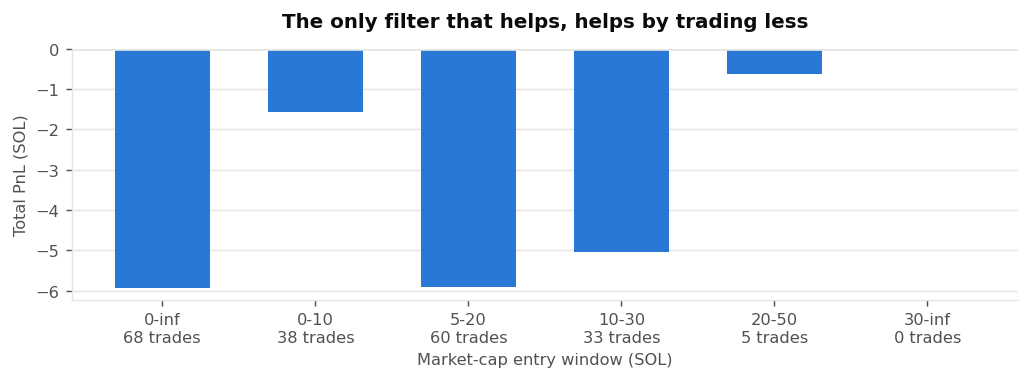

Restricting entries to sub-10 SOL market caps cuts the loss to **−1.558 SOL** — by skipping **30 of 68** entries. Avoiding a losing bet is not the same as finding a winning one.

In [7]:
mc = METRICS["mcSweep"]
labels = [m["label"] for m in mc]
vals = [m["totalPnl"] for m in mc]

fig, ax = plt.subplots(figsize=(8, 3))
ax.axhline(0, color=GRID, linewidth=1.5)
ax.bar(labels, vals, color=BLUE, width=0.62)
# Counts go under the tick labels: every bar here is negative, so a label at the
# bar tip runs into the axis.
ax.set_xticks(range(len(mc)), [f"{m['label']}\n{m['trades']} trades" for m in mc])
ax.set_xlabel("Market-cap entry window (SOL)")
ax.set_ylabel("Total PnL (SOL)")
ax.set_title("The only filter that helps, helps by trading less")
style(ax)
plt.tight_layout()
plt.show()

sub10 = next((m for m in mc if m["maxMcSol"] == 10), None)
if sub10:
    display(Markdown(
        f"Restricting entries to sub-10 SOL market caps cuts the loss to "
        f"**{sol(sub10['totalPnl'])}** — by skipping "
        f"**{base['trades'] - sub10['trades']} of {base['trades']}** entries. "
        f"Avoiding a losing bet is not the same as finding a winning one."
    ))

## The actual cause: you buy after the person you are copying

On a bonding curve, one slot of delay is not noise. The target's own buy moves the curve,
and so does every other bot reacting to the same public signal. By the time a copier's
transaction lands, the price it pays has already been pushed by the very event that
triggered it.

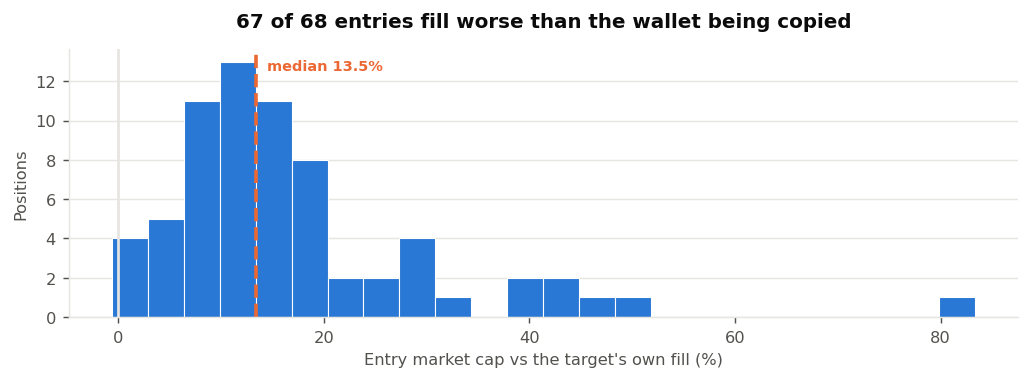

In [8]:
slips = [p["slippagePct"] for p in latency["perTrade"]]

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(slips, bins=24, color=BLUE, edgecolor="white", linewidth=0.6)
ax.axvline(0, color=GRID, linewidth=1.5)
ax.axvline(latency["medianSlippagePct"], color=ORANGE, linewidth=2, linestyle="--")
ax.annotate(
    f"median {pct(latency['medianSlippagePct'])}",
    xy=(latency["medianSlippagePct"], ax.get_ylim()[1]),
    xytext=(6, -12), textcoords="offset points",
    color=ORANGE, fontsize=8, fontweight="600",
)
ax.set_xlabel("Entry market cap vs the target's own fill (%)")
ax.set_ylabel("Positions")
ax.set_title(
    f"{latency['adverseCount']} of {latency['tradeCount']} entries fill worse "
    f"than the wallet being copied"
)
style(ax)
plt.tight_layout()
plt.show()

### What the same trades are worth without the delay

Holding the exit logic, the dataset, the fee assumption and the position list constant, and
changing only the entry price to the one the target wallet actually received:

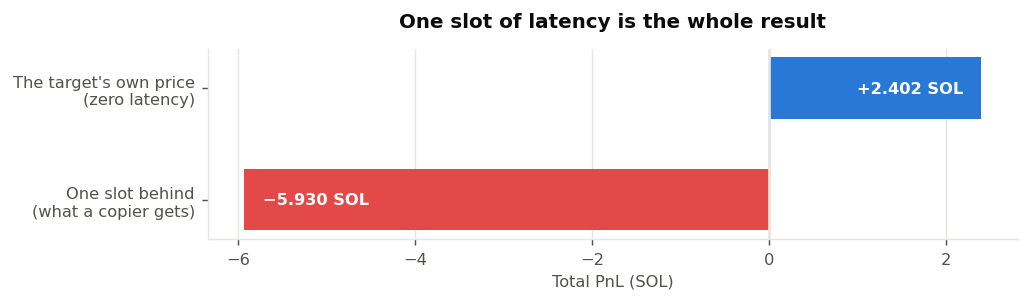

One slot of latency is worth **8.33 SOL** across 68 trades — about 0.123 SOL per trade, against an average position of 0.80 SOL. That is roughly **5.3× the total fees paid**, and it is the difference between a strategy that works and one that does not.

In [9]:
scen = [
    ("One slot behind\n(what a copier gets)", latency["actualPnl"]),
    ("The target's own price\n(zero latency)", latency["counterfactualPnl"]),
]
names = [s[0] for s in scen]
vals = [s[1] for s in scen]

fig, ax = plt.subplots(figsize=(8, 2.4))
ax.axvline(0, color=GRID, linewidth=1.5)
bars = ax.barh(names, vals, color=[RED if v < 0 else BLUE for v in vals], height=0.55)
for bar, v in zip(bars, vals):
    ax.annotate(
        sol(v),
        xy=(v, bar.get_y() + bar.get_height() / 2),
        xytext=(10 if v < 0 else -10, 0), textcoords="offset points",
        va="center", ha="left" if v < 0 else "right",
        fontweight="600", color="white",
    )
ax.set_xlabel("Total PnL (SOL)")
ax.set_title("One slot of latency is the whole result")
style(ax, grid_axis="x")
plt.tight_layout()
plt.show()

display(Markdown(
    f"One slot of latency is worth **{abs(latency['latencyCost']):.2f} SOL** across "
    f"{latency['tradeCount']} trades — about "
    f"{abs(latency['latencyCost'] / latency['tradeCount']):.3f} SOL per trade, against an "
    f"average position of {base['capitalDeployed'] / base['trades']:.2f} SOL. That is roughly "
    f"**{abs(latency['latencyCost']) / base['totalFees']:.1f}\u00d7 the total fees paid**, and "
    f"it is the difference between a strategy that works and one that does not."
))

In [10]:
display(Markdown(f"""## Conclusions

1. **Mirroring this wallet one slot late loses money** — {sol(base['totalPnl'])} over
   {base['trades']} round trips, {pct(base['winRate'])} win rate, profit factor
   {base['profitFactor']:.2f}.
2. **Exit tuning does not rescue it.** All {len(grid)} take-profit / stop-loss combinations
   lose, as does every trailing-stop and hold-time setting tested. The best cell still
   loses {sol(best['totalPnl'])}.
3. **The cost is at entry, not exit.** {latency['adverseCount']} of {latency['tradeCount']}
   fills are adverse, at a median {pct(latency['medianSlippagePct'])} worse market cap,
   costing {abs(latency['latencyCost']):.2f} SOL.
4. **The same trades at the target's price make {sol(latency['counterfactualPnl'])}.** The
   wallet's selection is genuinely profitable; the copying is what destroys it.
5. **So the engineering problem is execution latency** — co-location, a direct transaction
   feed, priority fees — not another risk parameter. A copy strategy evaluated without
   modelling entry delay will look profitable on paper and fail in production.

## Caveats

These bound what the result means, and every one of them makes the real outcome *worse*
than reported, not better:

- One target wallet, {METRICS['dataset']['tokenCount']} tokens,
  {METRICS['dataset']['tradeCount']:,} trades. This describes the sample, not pump.fun in
  general.
- Fees are modelled at a flat {METRICS['dataset']['feeRate'] * 100}% per side. Priority
  fees, tips and failed transactions are not modelled.
- Fills assume the replayed reserves absorb the simulated size with no impact beyond the
  curve maths, and competing bots chasing the same signal are not simulated.
- The zero-latency counterfactual is a *bound*, not an achievable target: it assumes a
  same-slot fill at the same price, which no observe-then-react bot gets.

---

*Generated from `{METRICS['dataset']['file']}`. Regenerate the data with
`npm run report:data`, then re-run this notebook with `npm run report`.*"""))

## Conclusions

1. **Mirroring this wallet one slot late loses money** — −5.930 SOL over
   68 round trips, 25.0% win rate, profit factor
   0.31.
2. **Exit tuning does not rescue it.** All 80 take-profit / stop-loss combinations
   lose, as does every trailing-stop and hold-time setting tested. The best cell still
   loses −2.586 SOL.
3. **The cost is at entry, not exit.** 67 of 68
   fills are adverse, at a median 13.5% worse market cap,
   costing 8.33 SOL.
4. **The same trades at the target's price make +2.402 SOL.** The
   wallet's selection is genuinely profitable; the copying is what destroys it.
5. **So the engineering problem is execution latency** — co-location, a direct transaction
   feed, priority fees — not another risk parameter. A copy strategy evaluated without
   modelling entry delay will look profitable on paper and fail in production.

## Caveats

These bound what the result means, and every one of them makes the real outcome *worse*
than reported, not better:

- One target wallet, 68 tokens,
  26,685 trades. This describes the sample, not pump.fun in
  general.
- Fees are modelled at a flat 1.5% per side. Priority
  fees, tips and failed transactions are not modelled.
- Fills assume the replayed reserves absorb the simulated size with no impact beyond the
  curve maths, and competing bots chasing the same signal are not simulated.
- The zero-latency counterfactual is a *bound*, not an achievable target: it assumes a
  same-slot fill at the same price, which no observe-then-react bot gets.

---

*Generated from `sample-data.json`. Regenerate the data with
`npm run report:data`, then re-run this notebook with `npm run report`.*